# McMurdie & Holmes (2013) — Reproduced with pyloseq

**Reference:** McMurdie PJ, Holmes S (2013). phyloseq: An R Package for Reproducible Interactive Analysis and Graphics of Microbiome Census Data. *PLoS ONE* 8(4): e61217.

This notebook reproduces the core analyses from the original phyloseq paper using the Python `pyloseq` package. It covers all four bundled datasets: **GlobalPatterns**, **enterotype**, **esophagus**, and **soilrep**.

## Coverage

| Analysis | Paper Figure | Status |
|---|---|---|
| GlobalPatterns preprocessing pipeline | — | ✅ |
| Alpha diversity — GlobalPatterns | Fig. 4 panel 1 | ✅ |
| Taxonomic bar chart — Bacteroidetes | Fig. 4 panel 2 | ✅ |
| Phylogenetic tree plot | Fig. 4 panel 3 | ✅ |
| Heatmap (Bray-Curtis NMDS ordering) | Fig. 4 panel 4 | ✅ |
| Ordination — NMDS + Weighted UniFrac | Fig. 5 panel 1 | ✅ |
| Ordination — CA (samples) | Fig. 5 panel 2 | ✅ |
| Ordination — CA (taxa / biplot / split) | Fig. 5 panels 3–5 | ✅ |
| Co-occurrence network — enterotype | Fig. 4 panel 5 | ✅ |
| Multiple hypothesis testing | Table 1 | ✅ `multi_tax_test` |
| UniFrac distances — esophagus | Methods | ✅ |
| Alpha diversity — soilrep | Methods | ✅ |

In [1]:
import numpy as np
import pandas as pd

from pyloseq import (
    OtuTable,
    Phyloseq,
    PhyTree,
    SampleData,
    TaxTable,
    distance,
    filter_taxa,
    kOverA,
    make_network,
    merge_samples,
    multi_tax_test,
    ordinate,
    plot_bar,
    plot_heatmap,
    plot_network,
    plot_ordination,
    plot_richness,
    plot_tree,
    subset_samples,
    subset_taxa,
    tip_glom,
    transform_sample_counts,
)
from pyloseq.datasets import (
    load_enterotype_reference,
    load_esophagus_reference,
    load_global_patterns_reference,
    load_soilrep_reference,
)

---
## Dataset 1: GlobalPatterns

**Original study:** Caporaso et al. (2011), *PNAS*

16S rRNA amplicon sequencing of 26 environmental samples across 9 sample types with ~19,216 OTUs and a phylogenetic tree. This is the primary dataset used in the paper to demonstrate the full pyloseq analysis pipeline.

### 1.1 Load and Inspect

In [2]:
raw_gp = load_global_patterns_reference()

gps = Phyloseq(
    otu=OtuTable(raw_gp["otu_table"]),
    sam=SampleData(raw_gp["sample_data"]),
    tax=TaxTable(raw_gp["tax_table"]),
    tree=PhyTree.from_newick(raw_gp["phy_tree_newick"]),
)

print(f"Taxa:    {gps.ntaxa}")
print(f"Samples: {gps.nsamples}")
print(f"Ranks:   {gps.rank_names}")
print(f"Sample variables: {gps.sample_variables}")

Taxa:    19216
Samples: 26
Ranks:   ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
Sample variables: ['X.SampleID', 'Primer', 'Final_Barcode', 'Barcode_truncated_plus_T', 'Barcode_full_length', 'SampleType', 'Description']


In [3]:
gps.sample_data.to_frame().head()

,X.SampleID,Primer,Final_Barcode,Barcode_truncated_plus_T,Barcode_full_length,SampleType,Description
CL3,CL3,ILBC_01,AACGCA,TGCGTT,CTAGCGTGCGT,Soil,"Calhoun South Carolina Pine soil, pH 4.9"
CC1,CC1,ILBC_02,AACTCG,CGAGTT,CATCGACGAGT,Soil,"Cedar Creek Minnesota, grassland, pH 6.1"
SV1,SV1,ILBC_03,AACTGT,ACAGTT,GTACGCACAGT,Soil,"Sevilleta new Mexico, desert scrub, pH 8.3"
M31Fcsw,M31Fcsw,ILBC_04,AAGAGA,TCTCTT,TCGACATCTCT,Feces,"M3, Day 1, fecal swab, whole body study"
M11Fcsw,M11Fcsw,ILBC_05,AAGCTG,CAGCTT,CGACTGCAGCT,Feces,"M1, Day 1, fecal swab, whole body study"


### 1.2 Preprocessing Pipeline

The paper applies a five-step preprocessing pipeline to GlobalPatterns before most analyses:

1. Add a `human` vs `non-human` binary variable (Human = Feces, Mock, Skin, Tongue)
2. Remove OTUs not seen more than 3 times in at least 20% of samples
3. Normalize each sample to the median sequencing depth
4. Remove OTUs with coefficient of variation (CV) ≤ 3.0
5. Subset to **Bacteroidetes** only (for select figures)

In [4]:
# Step 1: Add human vs. non-human binary variable
human_types = {"Feces", "Mock", "Skin", "Tongue"}
sam_df = gps.sample_data.to_frame().copy()
sam_df["human"] = sam_df["SampleType"].isin(human_types)

gps = Phyloseq(
    otu=gps.otu_table,
    sam=SampleData(sam_df),
    tax=gps.tax_table,
    tree=gps.phy_tree,
)

print("human variable added:")
print(gps.sample_data.to_frame()[["SampleType", "human"]].to_string())

human variable added:
                  SampleType  human
CL3                     Soil  False
CC1                     Soil  False
SV1                     Soil  False
M31Fcsw                Feces   True
M11Fcsw                Feces   True
M31Plmr                 Skin   True
M11Plmr                 Skin   True
F21Plmr                 Skin   True
M31Tong               Tongue   True
M11Tong               Tongue   True
LMEpi24M          Freshwater  False
SLEpi20M          Freshwater  False
AQC1cm    Freshwater (creek)  False
AQC4cm    Freshwater (creek)  False
AQC7cm    Freshwater (creek)  False
NP2                    Ocean  False
NP3                    Ocean  False
NP5                    Ocean  False
TRRsed1   Sediment (estuary)  False
TRRsed2   Sediment (estuary)  False
TRRsed3   Sediment (estuary)  False
TS28                   Feces   True
TS29                   Feces   True
Even1                   Mock   True
Even2                   Mock   True
Even3                   Mock   True


In [5]:
# Step 2: Filter OTUs not seen more than 3 times in at least 20% of samples.
# kOverA(k, A) keeps a taxon if at least k samples have abundance > A.
k = int(0.2 * gps.nsamples)  # 20% of 26 samples → 5
gpsf = filter_taxa(gps, kOverA(k=k, A=3))

print(f"Before filter: {gps.ntaxa} taxa")
print(f"After filter:  {gpsf.ntaxa} taxa  (k={k}, A=3)")

Before filter: 19216 taxa
After filter:  3641 taxa  (k=5, A=3)


In [6]:
# Step 3: Normalize each sample's counts to the median sequencing depth across samples.
# R equivalent: standf = function(x, t=total) round(t * (x / sum(x)))
median_depth = float(np.median(gpsf.sample_sums()))
print(f"Median sequencing depth: {median_depth:,.0f}")

gpsf = transform_sample_counts(
    gpsf,
    lambda x: np.round(x / x.sum() * median_depth),
)

print(f"Sample depth range after normalization: "
      f"{gpsf.sample_sums().min():.0f} – {gpsf.sample_sums().max():.0f}")

Median sequencing depth: 1,015,084
Sample depth range after normalization: 1014694 – 1015459


In [7]:
# Step 4: Filter OTUs with CV ≤ 3.0 (keep high-variance OTUs).
# CV = std / mean; protects against OTUs with small mean and inflated CV.
def cv_above(threshold):
    def _predicate(x):
        m = x.mean()
        return (x.std() / m) > threshold if m > 0 else False
    return _predicate

gpsf = filter_taxa(gpsf, cv_above(3.0))
print(f"After CV filter: {gpsf.ntaxa} taxa")

After CV filter: 1746 taxa


In [8]:
# Step 5: Subset to Bacteroidetes only.
gpsfb = subset_taxa(gpsf, 'Phylum == "Bacteroidetes"')

print(f"Bacteroidetes subset: {gpsfb.ntaxa} taxa, {gpsfb.nsamples} samples")

Bacteroidetes subset: 262 taxa, 26 samples


### 1.3 Alpha Diversity — Figure 4, Panel 6

Alpha diversity is estimated on the **unfiltered** `gps` object. The paper emphasizes that richness estimation (especially Chao1) must precede abundance filtering, because filters remove rare OTUs that Chao1 uses to correct for unseen species.

The paper's final published plot maps **human vs. non-human** (`human=True/False`) to the x-axis and sample type to color, matching R's `plot_richness(GlobalPatterns, "human", "SampleType")`.

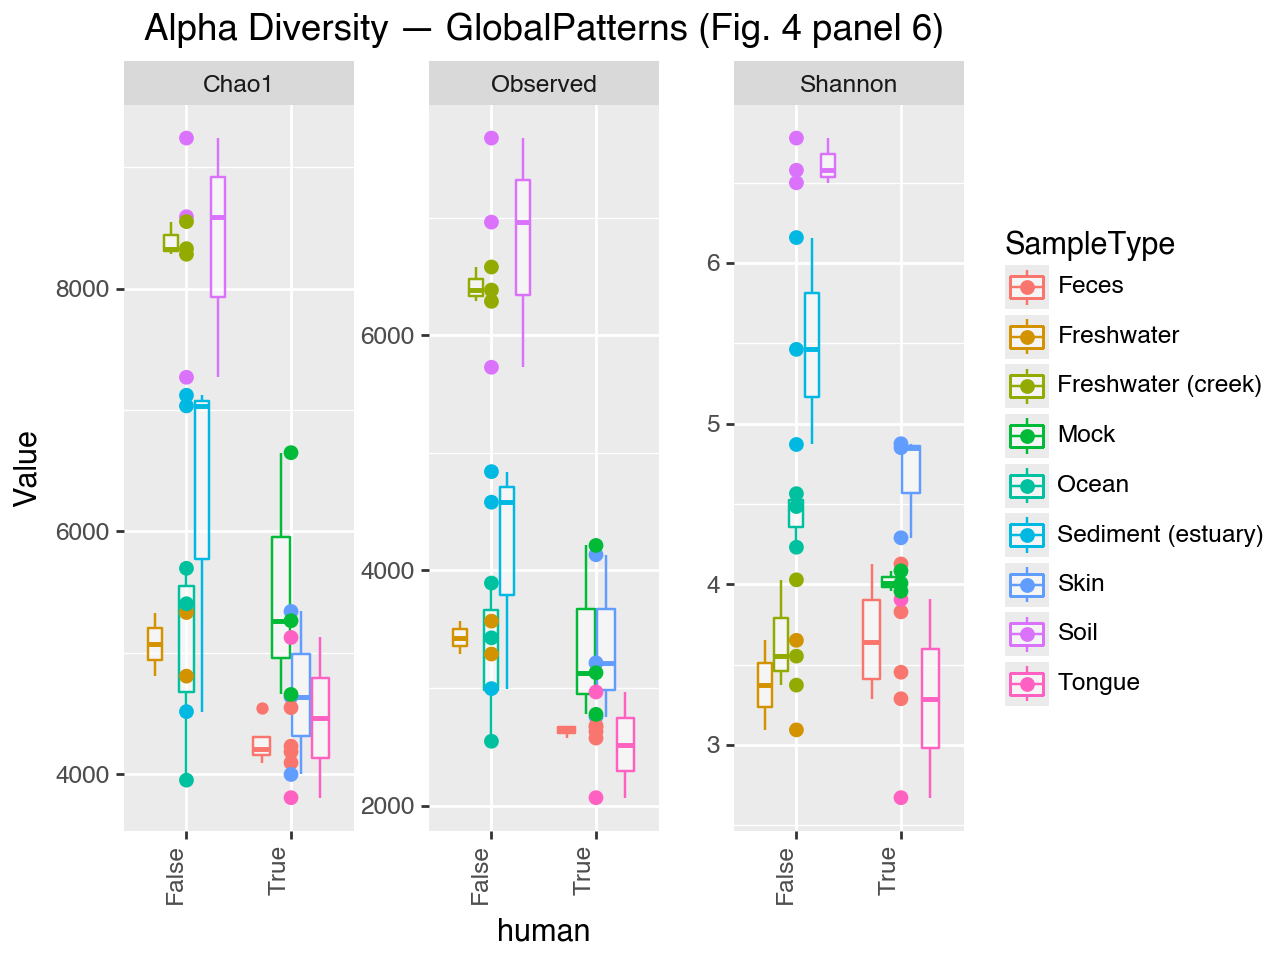

In [9]:
# Figure 4, panel 6: alpha diversity — human vs. non-human on x-axis
# R: plot_richness(GlobalPatterns, "human", "SampleType", title="plot_richness")
p = plot_richness(
    gps,
    x="human",
    color="SampleType",
    measures=["Observed", "Chao1", "Shannon"],
    title="Alpha Diversity — GlobalPatterns (Fig. 4 panel 6)",
)
p

### 1.4 Taxonomic Bar Chart — Figure 4, Panel 2

Stacked bar chart using the **Bacteroidetes-only** subset (`gpsfb`). Each bar represents a sample type; fill color shows the contributing Family.

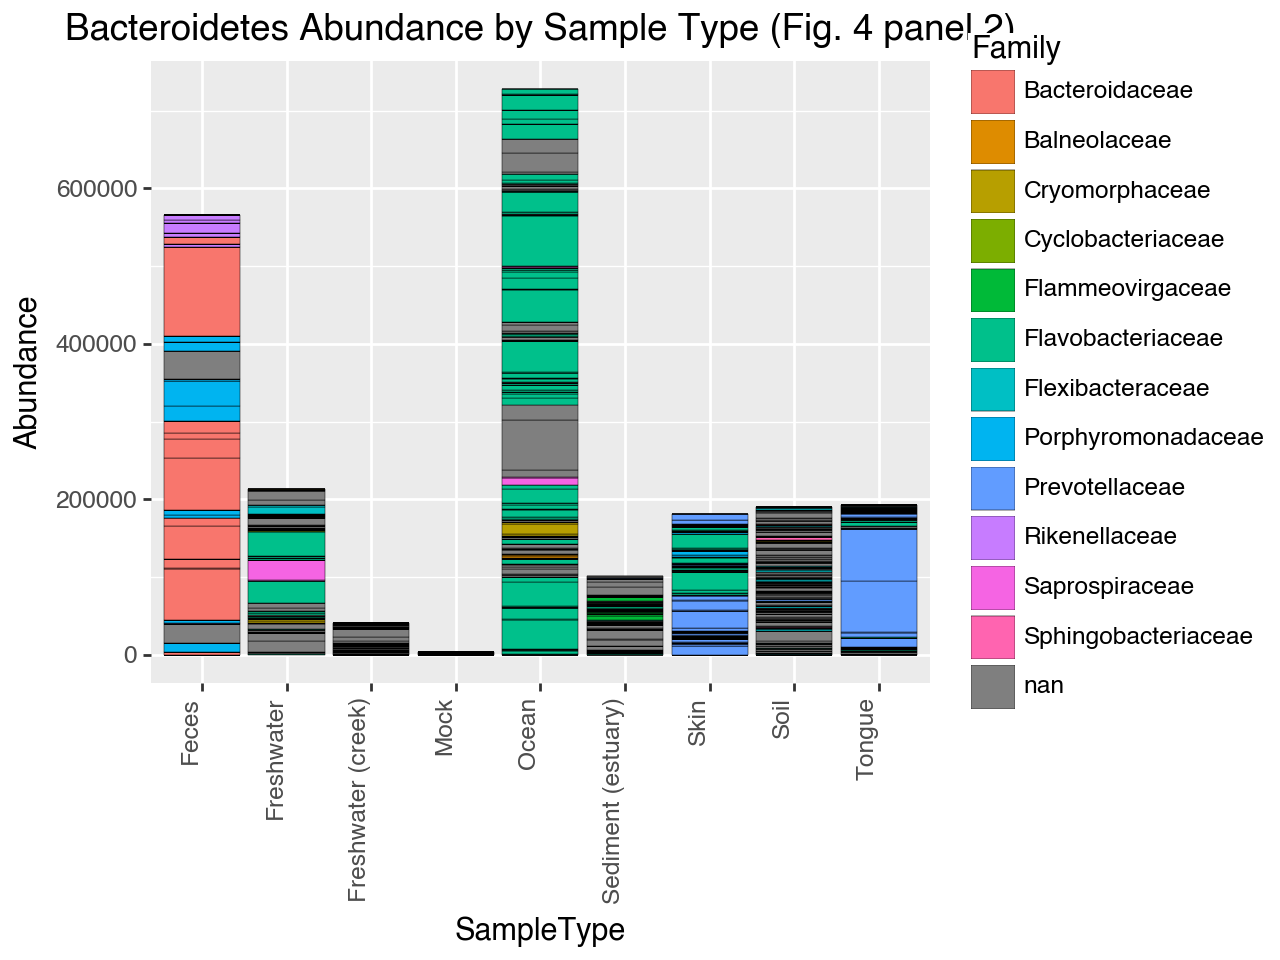

In [10]:
# Figure 4, panel 2: Bacteroidetes bar chart colored by Family
p = plot_bar(
    gpsfb,
    x="SampleType",
    fill="Family",
    title="Bacteroidetes Abundance by Sample Type (Fig. 4 panel 2)",
)
p

### 1.5 Phylogenetic Tree — Figure 4, Panel 4

The paper uses `plot_tree()` with `method='sampledodge'` to draw one dot per sample at each tip. The raw `gpsfb` (261 Bacteroidetes OTUs across 26 samples) is too crowded, so the paper applies two simplification steps before plotting:

1. **`tip_glom(gpsfb, h=0.1)`** — agglomerate OTUs whose pairwise patristic distance is ≤ 0.1 into single cluster representatives, reducing the tip count
2. **`merge_samples(tggpsfb, "SampleType")`** — collapse per-individual samples into per-environment profiles, so each of the 9 sample types becomes one merged sample

After merging, the `human` and `SampleType` metadata columns are repaired (numeric aggregation during merge makes them meaningless) and then the tree is plotted.

After tip_glom:      110 taxa (from 262)
After merge_samples: 9 samples (unique SampleTypes)
Sample names:        ['Feces', 'Freshwater', 'Freshwater (creek)', 'Mock', 'Ocean', 'Sediment (estuary)', 'Skin', 'Soil', 'Tongue']


/Users/michaeldonovan/pyloseq/src/pyloseq/_manipulation.py:915: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/michaeldonovan/pyloseq/src/pyloseq/_manipulation.py:927: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/michaeldonovan/pyloseq/venv/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 66 rows containing missing values.


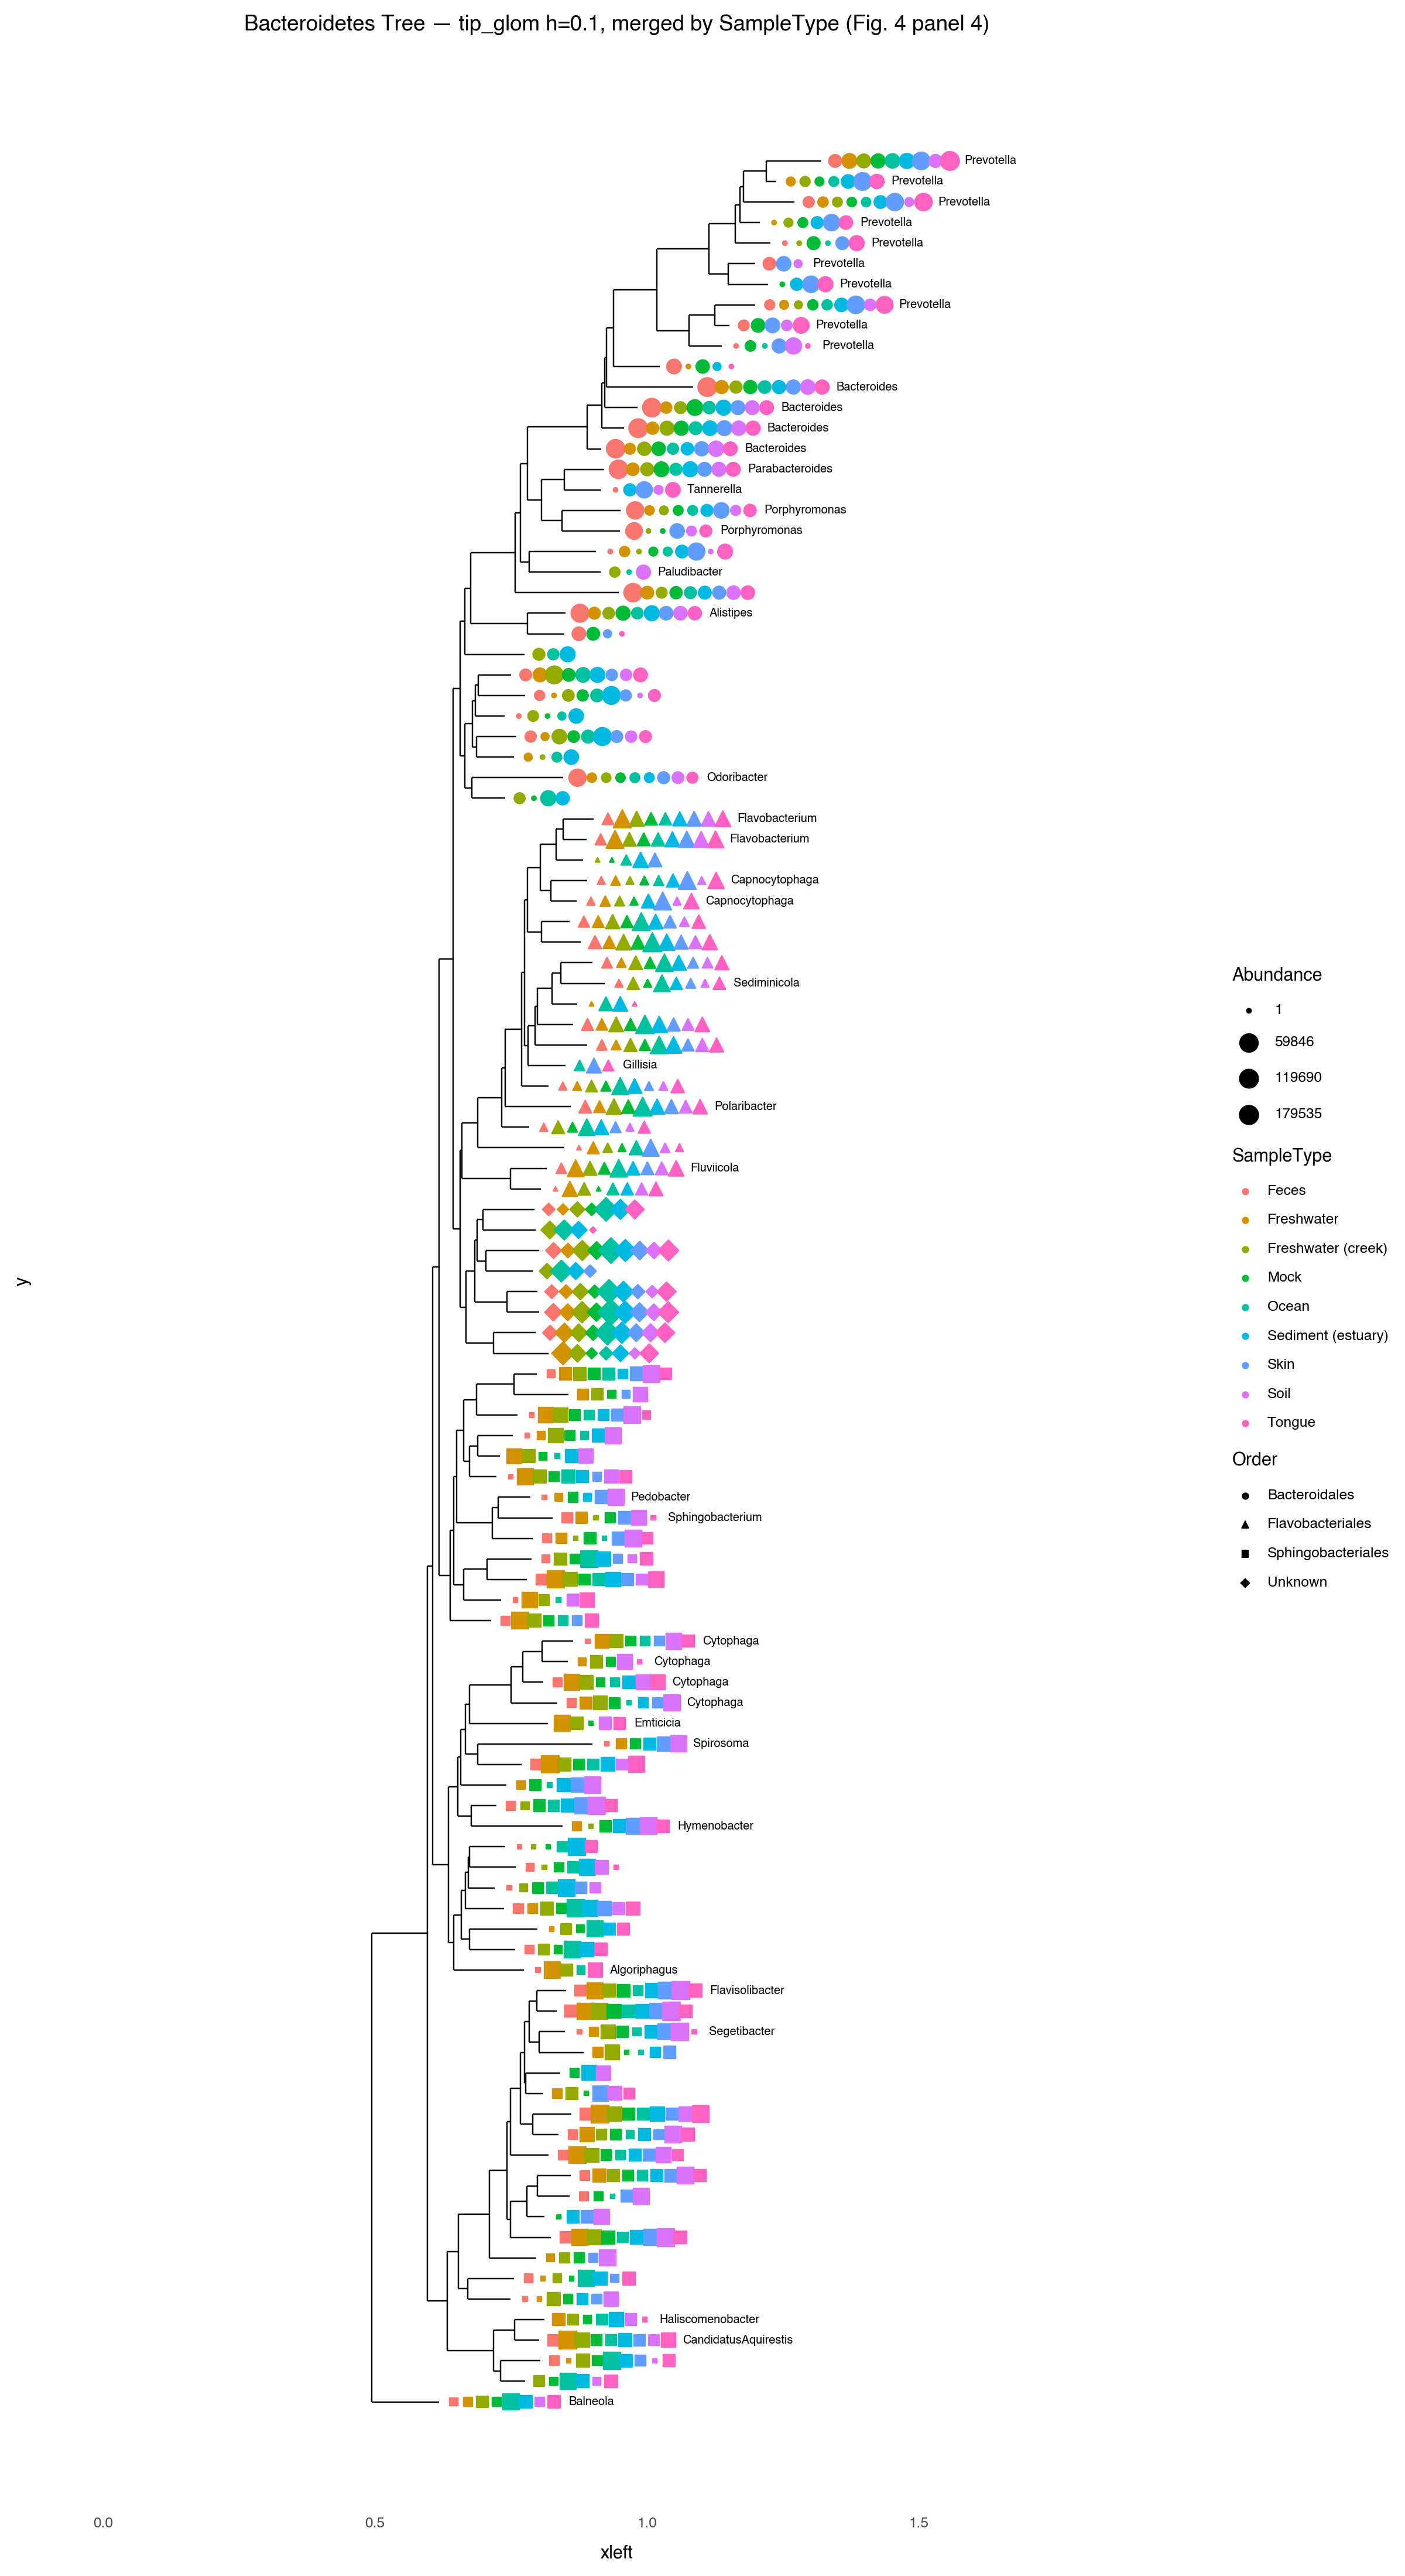

In [11]:
# Step 1: Phylogenetic agglomeration — merge OTUs with patristic distance ≤ 0.1
# R: tip_glom(gpsfb, NULL, 0.1)
tggpsfb = tip_glom(gpsfb, h=0.1)
print(f"After tip_glom:      {tggpsfb.ntaxa} taxa (from {gpsfb.ntaxa})")

# Step 2: Merge per-individual samples into per-environment profiles
# R: merge_samples(tggpsfb, "SampleType")
tggpsfb = merge_samples(tggpsfb, "SampleType")
print(f"After merge_samples: {tggpsfb.nsamples} samples (unique SampleTypes)")
print(f"Sample names:        {list(tggpsfb.sample_names)}")

# Repair human + SampleType variables — numeric aggregation during merge corrupts them
human_types = {"Feces", "Mock", "Skin", "Tongue"}
new_names = list(tggpsfb.sample_names)
sam_df_tree = tggpsfb.sample_data.to_frame().copy()
sam_df_tree["human"] = [name in human_types for name in new_names]
sam_df_tree["SampleType"] = new_names
tggpsfb = Phyloseq(
    otu=tggpsfb.otu_table,
    sam=SampleData(sam_df_tree),
    tax=tggpsfb.tax_table,
    tree=tggpsfb.phy_tree,
)

# Figure 4, panel 4: phylogenetic tree with per-environment sample points
# R: plot_tree(tggpsfb, "sampledodge", nodeplotboot(85,60), "SampleType", "Order", "abundance", ...)
p = plot_tree(
    tggpsfb,
    method="sampledodge",
    color="SampleType",
    shape="Order",
    size="Abundance",
    label_tips="Genus",
    ladderize="left",
    title="Bacteroidetes Tree — tip_glom h=0.1, merged by SampleType (Fig. 4 panel 4)",
)
p

### 1.6 Heatmap — Figure 4, Panel 4

Abundance heatmap of the **full preprocessed** dataset (`gpsf`). Samples and taxa are reordered by the first axis of an NMDS ordination on Bray-Curtis distances, which groups similar communities together visually.

/Users/michaeldonovan/pyloseq/src/pyloseq/_ordination.py:79: UserWarning: Neither scikit-bio nmds nor scikit-learn is available; falling back to classical (metric) MDS. The result is metric MDS (equivalent to PCoA), not non-metric NMDS. Install scikit-learn for true NMDS.


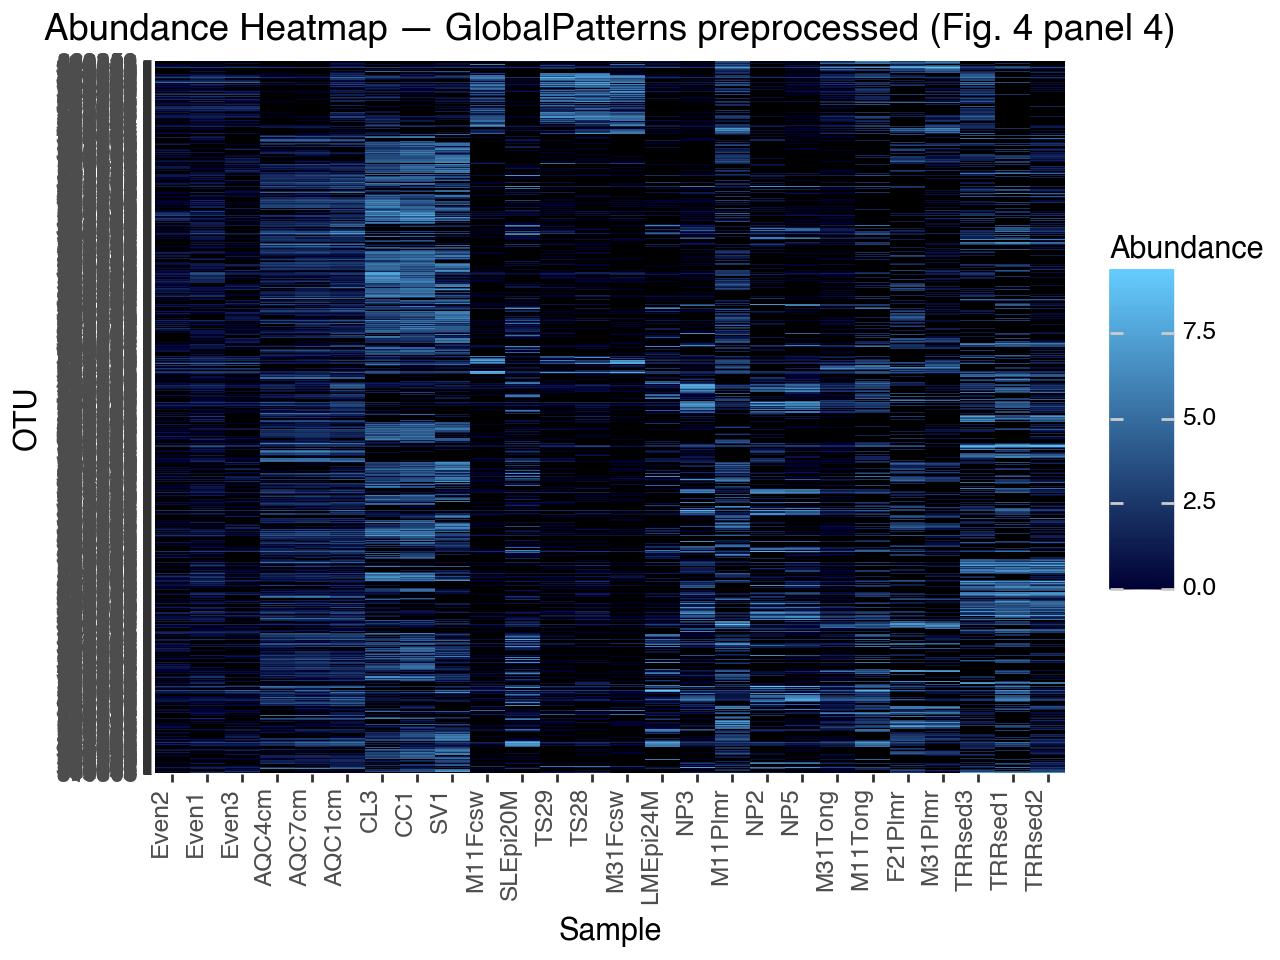

In [12]:
# Figure 4, panel 4: heatmap on preprocessed GlobalPatterns, NMDS/Bray-Curtis ordering
p = plot_heatmap(
    gpsf,
    method="NMDS",
    distance="bray",
    trans="log4",
    title="Abundance Heatmap — GlobalPatterns preprocessed (Fig. 4 panel 4)",
)
p

### Figure 4 — Composition

The R paper's **Figure 4** is a 3×2 grid combining six panels from across different datasets:

| Position | R panel | Dataset | This notebook |
|---|---|---|---|
| row 1, col 1 | p1 — NMDS + Weighted UniFrac | GlobalPatterns/Bacteroidetes | §1.7 ordination cell |
| row 1, col 2 | p2 — Heatmap (Bray-Curtis, NMDS) | GlobalPatterns preprocessed | §1.6 above |
| row 2, col 1 | p3 — Co-occurrence network | Enterotype | §2.2 below |
| row 2, col 2 | p4 — Phylogenetic tree | Bacteroidetes tip_glom | §1.5 above |
| row 3, col 1 | p5 — Taxonomic bar chart | Bacteroidetes | §1.4 above |
| row 3, col 2 | p6 — Alpha diversity | GlobalPatterns (unfiltered) | §1.3 above |


### 1.7 Ordination — Figure 5

All ordinations use the **Bacteroidetes-only** subset (`gpsfb`).

**Panel 1 (NMDS + Weighted UniFrac):** NMDS on the weighted UniFrac distance matrix, samples colored by `SampleType`.

**CA scree inset:** Proportion explained by each CA axis, displayed as a small inset in the R paper. In R the axis labels were stripped with `element_blank()` for a clean inset appearance.

**Panel 2 (CA samples):** Correspondence Analysis samples plot colored by `SampleType` with convex hull shading.

**Panel 3 (CA taxa):** Taxa-only CA plot faceted by taxonomic `Class` with 2-D kernel density contours (`geom_density_2d`), shaped by Class.

**Panel 4 (CA biplot):** Samples and taxa overlaid, with taxa shaped by `Class` and sample rows labelled `"samples"` in the Class legend (matching R's legend re-ordering).

**Panel 5 (CA split):** Samples and taxa in side-by-side faceted panels.

/Users/michaeldonovan/pyloseq/src/pyloseq/_ordination.py:79: UserWarning: Neither scikit-bio nmds nor scikit-learn is available; falling back to classical (metric) MDS. The result is metric MDS (equivalent to PCoA), not non-metric NMDS. Install scikit-learn for true NMDS.


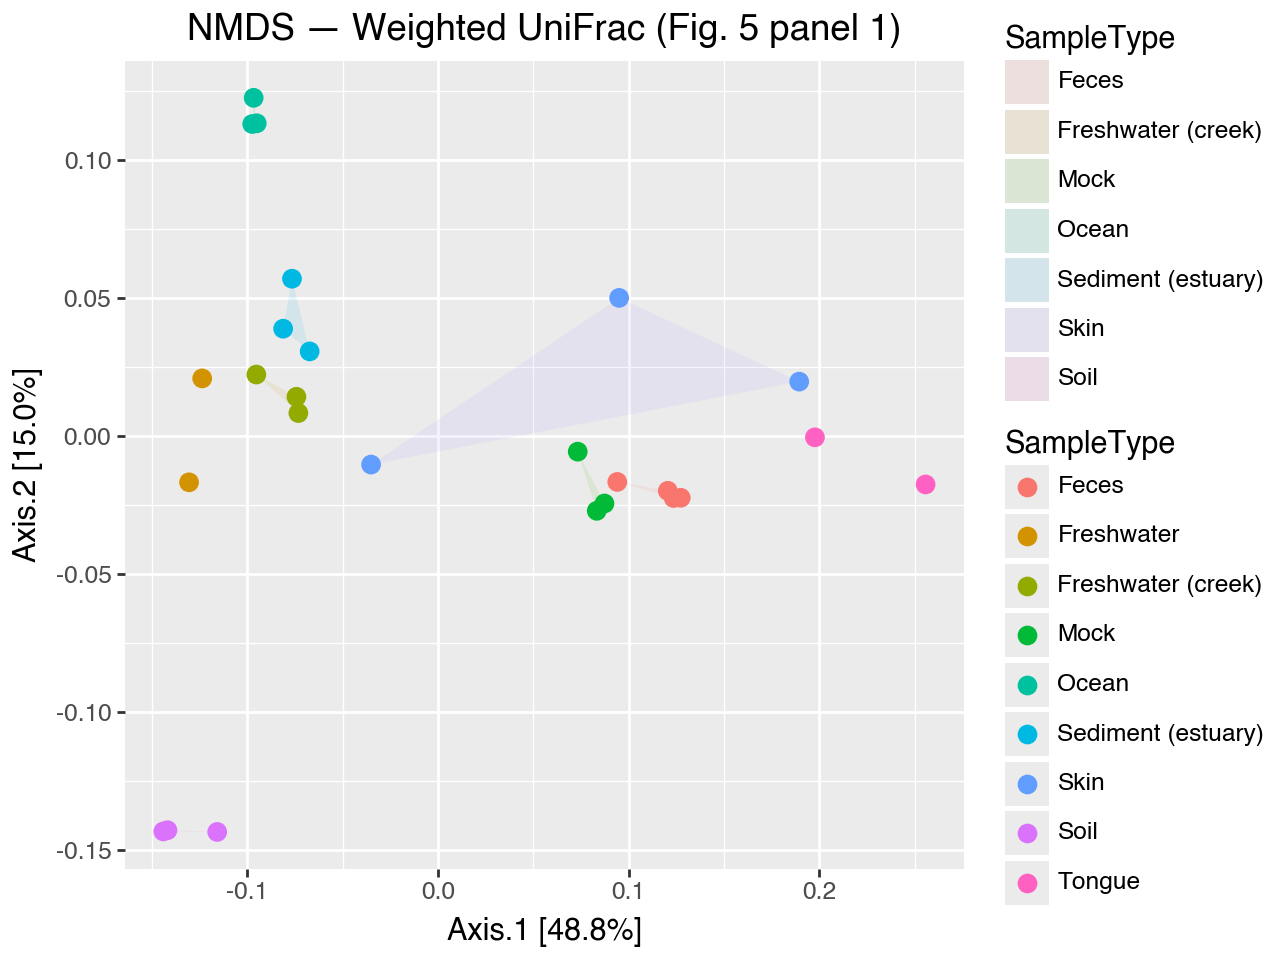

In [13]:
# Figure 5, panel 1: NMDS + Weighted UniFrac (samples colored by SampleType)
ord_nmds = ordinate(gpsfb, method="NMDS", distance="wunifrac")

p1 = plot_ordination(
    gpsfb,
    ord_nmds,
    kind="samples",
    color="SampleType",
    show_hull=True,
    title="NMDS — Weighted UniFrac (Fig. 5 panel 1)",
)
p1

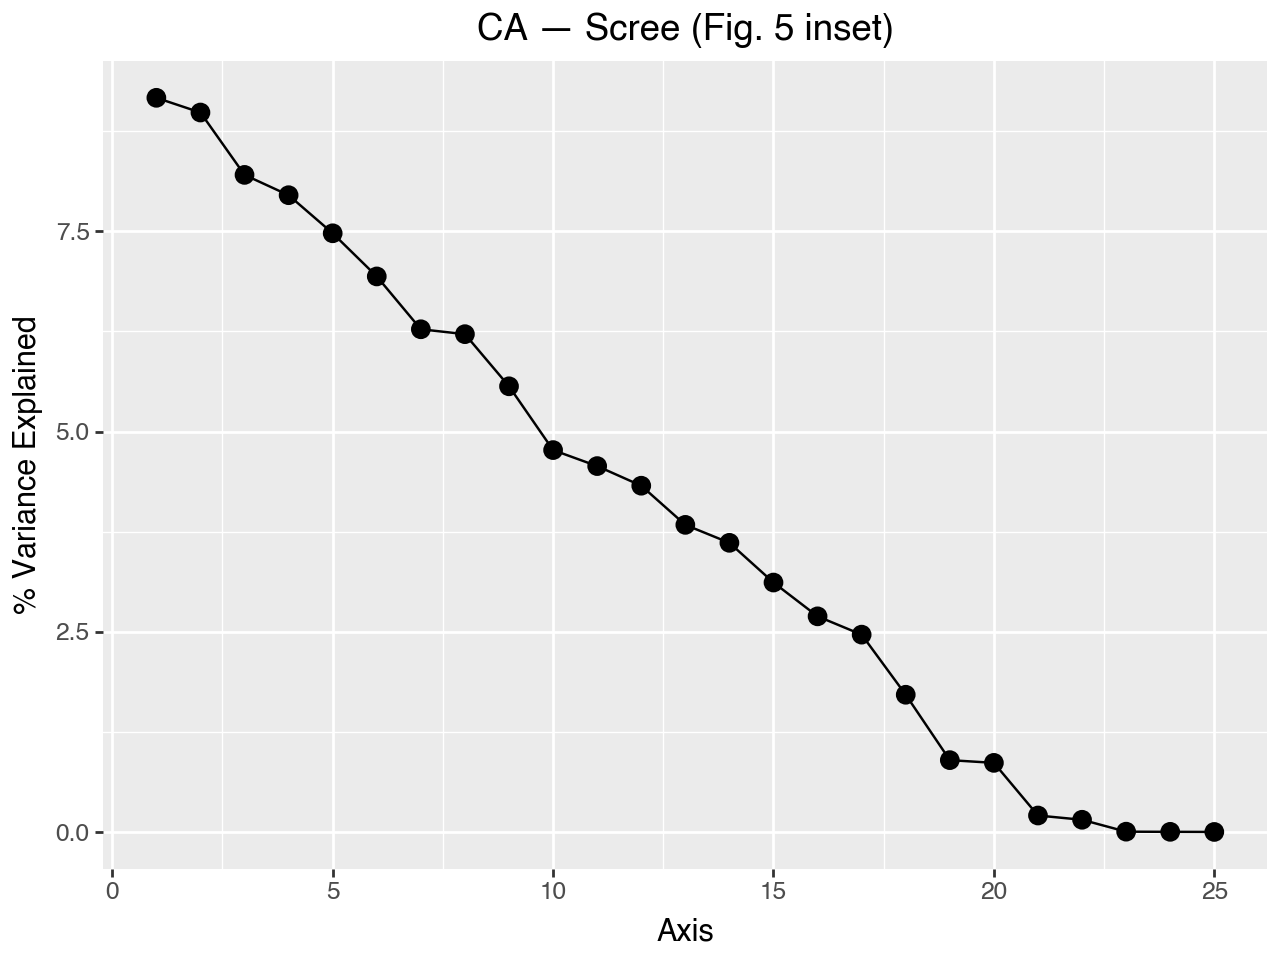

In [14]:
# Figure 5: Correspondence Analysis (CA)
# R uses ordinate(gpsfb, method="CCA") — without a formula this is unconstrained CA
ord_ca = ordinate(gpsfb, method="CA")

# Scree plot — proportion of variance explained per axis (shown as inset in R paper Fig. 5)
# R: p0 = plot_ordination(gpsfb, GP.ca, "scree", title=...)
p_scree = plot_ordination(
    gpsfb, ord_ca, kind="scree",
    title="CA — Scree (Fig. 5 inset)",
)
p_scree

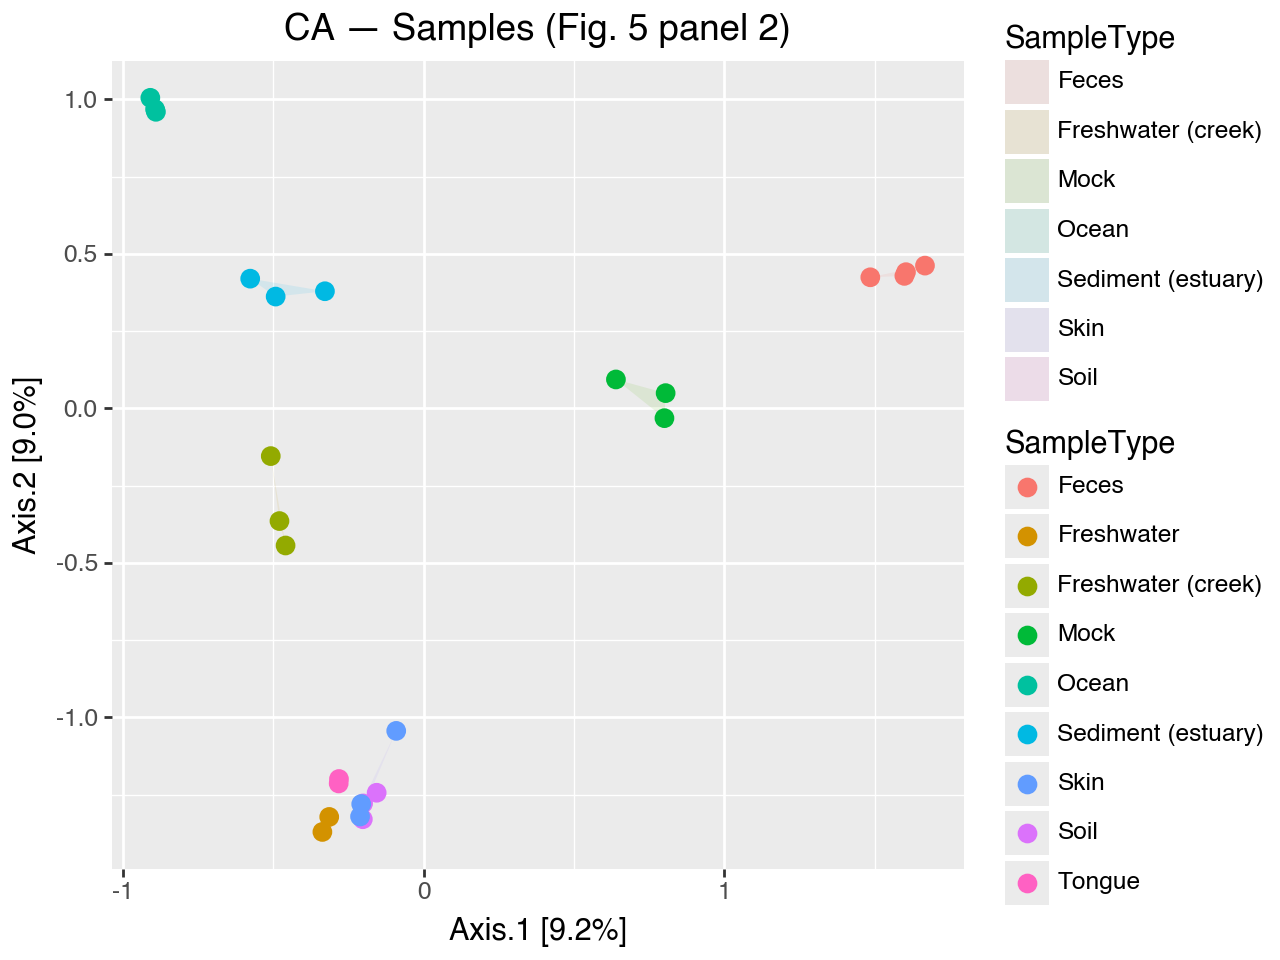

In [15]:
# Figure 5, panel 2: CA — samples colored by SampleType with convex hull regions
# R: p1 = plot_ordination(gpsfb, GP.ca, "samples", color="SampleType", ...)
#    p1 = p1 + geom_polygon(aes(fill=SampleType)) + geom_point(size=5)
p2 = plot_ordination(
    gpsfb,
    ord_ca,
    kind="samples",
    color="SampleType",
    show_hull=True,
    title="CA — Samples (Fig. 5 panel 2)",
)
p2

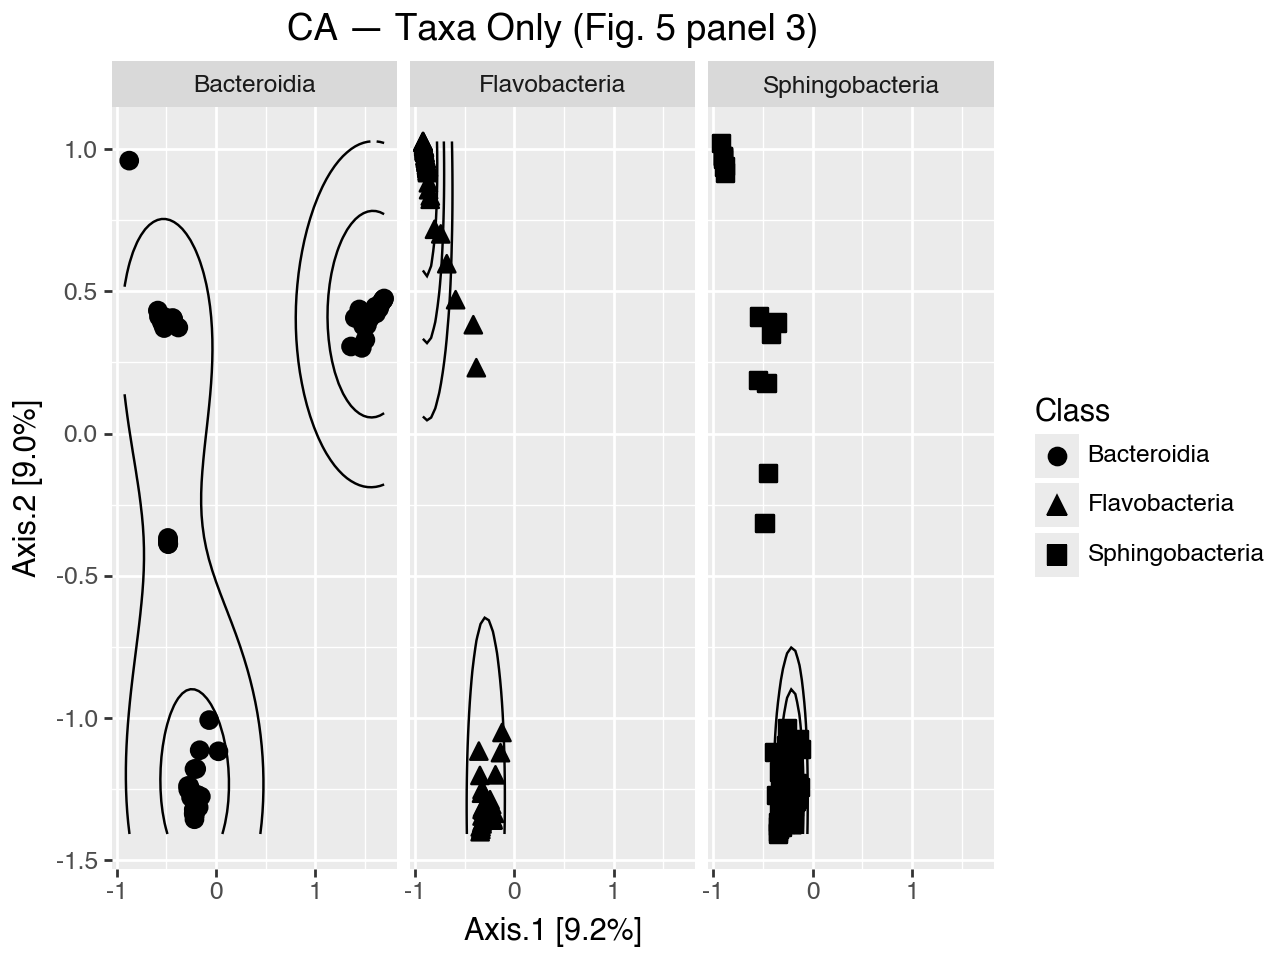

In [ ]:
from plotnine import facet_wrap, geom_density_2d

# Figure 5, panel 3: CA — taxa only, faceted by Class with 2-D density contours
# R: p3 + facet_wrap(~Class, nrow=1) + geom_density2d()

p3 = plot_ordination(
    gpsfb, ord_ca, kind="taxa",
    shape="Class",
    title="CA — Taxa Only (Fig. 5 panel 3)",
)
p3 = p3 + facet_wrap("~Class", nrow=1) + geom_density_2d()
p3

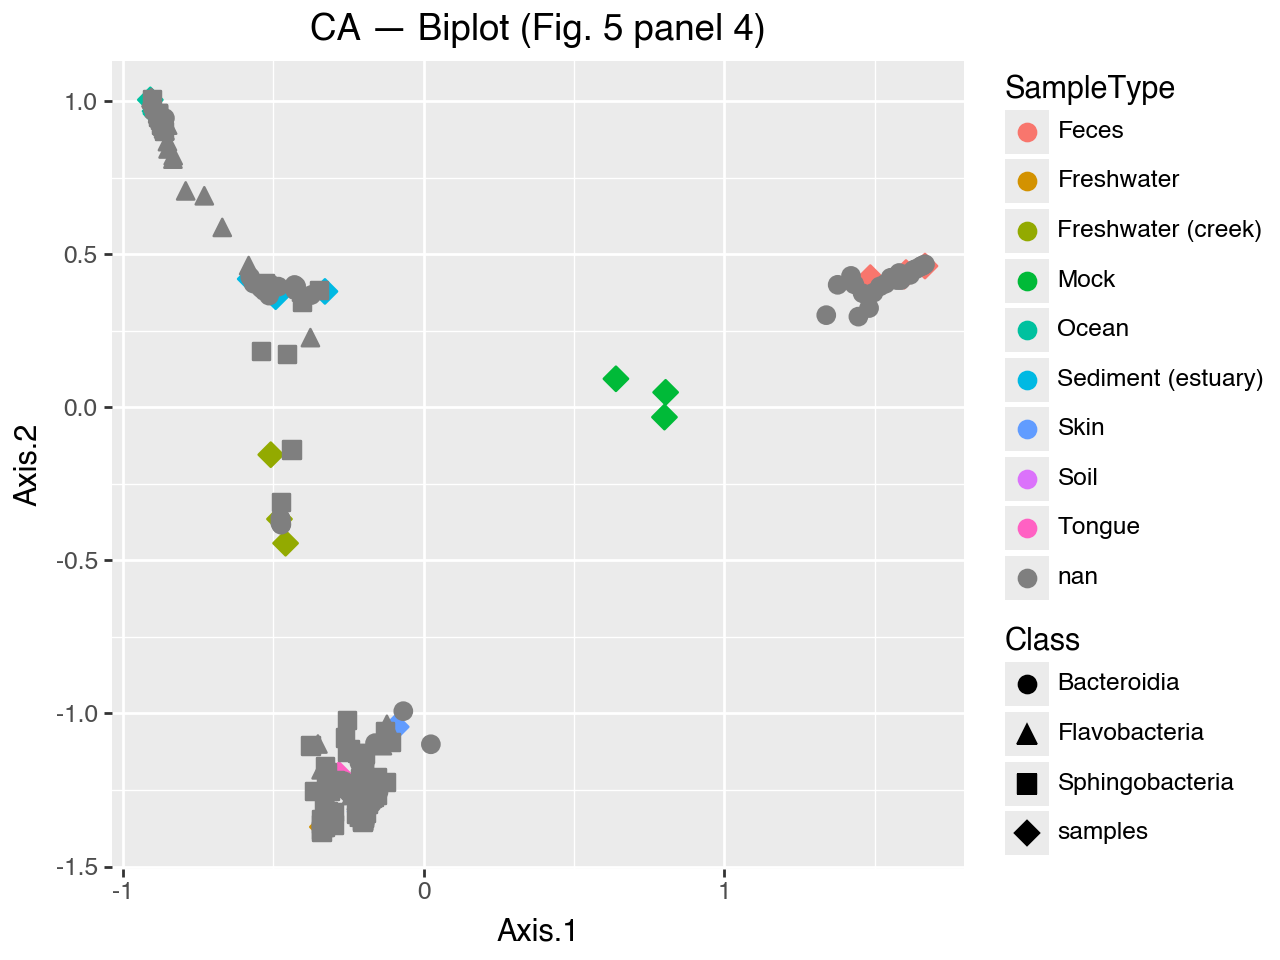

In [ ]:
from plotnine import aes, geom_point, ggplot, labs

# Figure 5, panel 4: CA — biplot (samples + taxa overlaid)
# R: plot_ordination(gpsfb, GP.ca, "biplot", color="SampleType", shape="Class", ...)
# Sample rows don't have a Class value; we label them "samples" to match R's legend handling.
biplot_df = plot_ordination(gpsfb, ord_ca, kind="biplot", just_df=True)
if "Class" in biplot_df.columns:
    biplot_df["Class"] = biplot_df["Class"].fillna("samples")

p4 = (
    ggplot(biplot_df, aes(x="Axis.1", y="Axis.2", color="SampleType", shape="Class"))
    + geom_point(size=3)
    + labs(title="CA — Biplot (Fig. 5 panel 4)")
)
p4

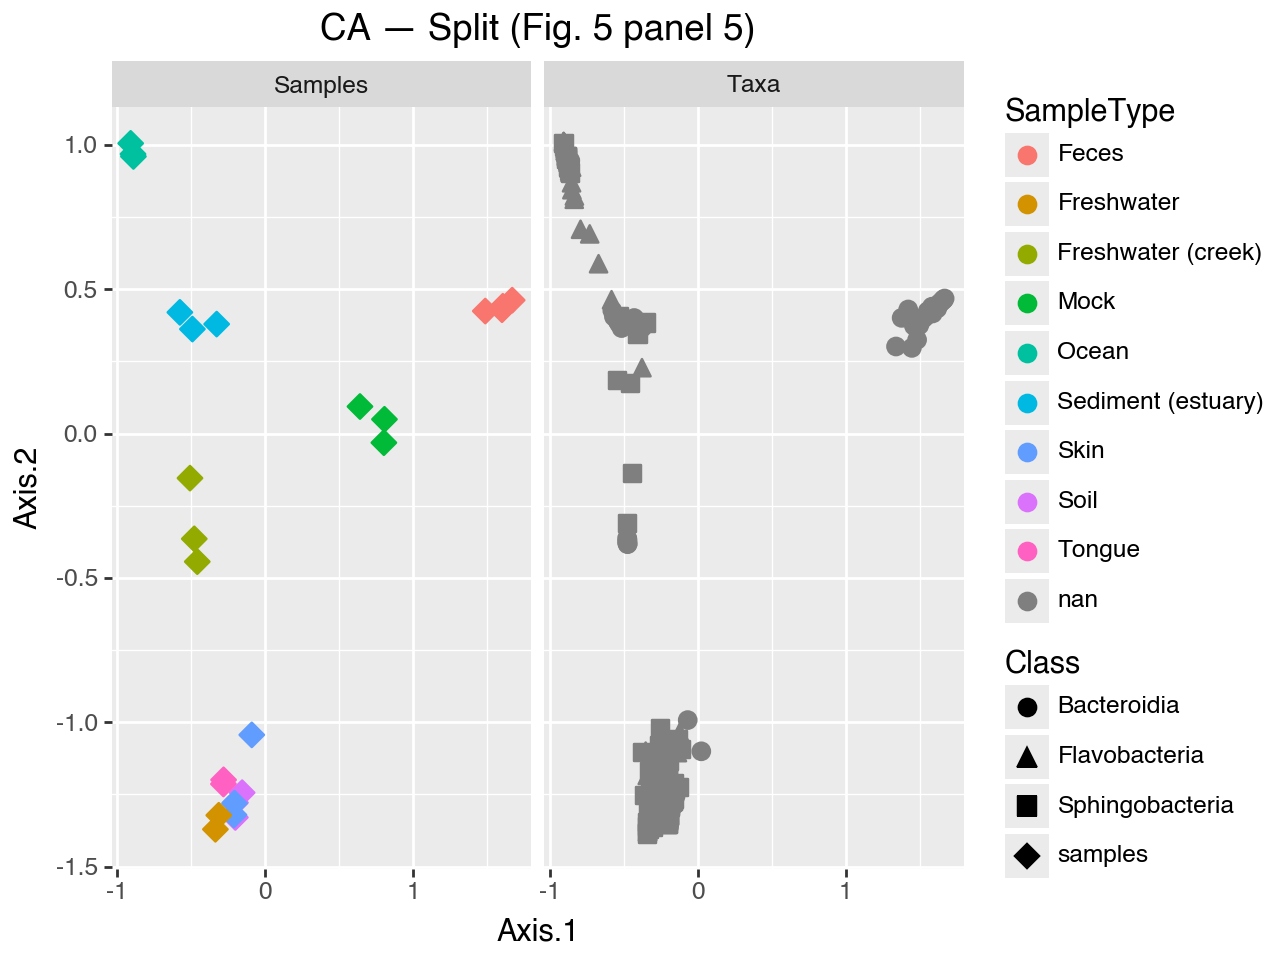

In [ ]:
from plotnine import aes, facet_wrap, geom_point, ggplot, labs

# Figure 5, panel 5: CA — split (samples and taxa in side-by-side panels)
# R: plot_ordination(gpsfb, GP.ca, "split", color="SampleType", shape="Class", ...)
# Sample rows get Class="samples" (no tax_table Class); taxa rows keep their Class.
split_df = plot_ordination(gpsfb, ord_ca, kind="split", just_df=True)
if "Class" in split_df.columns:
    split_df["Class"] = split_df["Class"].fillna("samples")

p5 = (
    ggplot(split_df, aes(x="Axis.1", y="Axis.2", color="SampleType", shape="Class"))
    + geom_point(size=3)
    + facet_wrap("~_panel")
    + labs(title="CA — Split (Fig. 5 panel 5)")
)
p5

### Figure 5 — Combined

The five panels above (**scree inset**, **CA samples**, **CA taxa+density**, **CA biplot**, **CA split**) reproduce the ordination figure (Figure 5) from the paper. In R, these were combined with `grid.newpage()` and the scree plot embedded as a small inset viewport over the samples panel. The scree plot axes were stripped (`axis.title`, `axis.ticks`, `axis.text` set to `element_blank()`) to give it an uncluttered inset appearance.

---
## Dataset 2: Enterotype

**Original study:** Arumugam et al. (2011), *Nature*

Shotgun metagenomics of 280 human faecal samples at genus level. Samples are classified into three enterotypes and profiled with different sequencing technologies. No phylogenetic tree.

### 2.1 Load and Inspect

In [19]:
raw_et = load_enterotype_reference()

enterotype = Phyloseq(
    otu=OtuTable(raw_et["otu_table"]),
    sam=SampleData(raw_et["sample_data"]),
    tax=TaxTable(raw_et["tax_table"]),
)

print(f"Taxa:    {enterotype.ntaxa}")
print(f"Samples: {enterotype.nsamples}")
print(f"Sample variables: {enterotype.sample_variables}")

Taxa:    553
Samples: 280
Sample variables: ['Enterotype', 'Sample_ID', 'SeqTech', 'SampleID', 'Project', 'Nationality', 'Gender', 'Age', 'ClinicalStatus']


In [20]:
enterotype.sample_data.to_frame().head(10)

,Enterotype,Sample_ID,SeqTech,SampleID,Project,Nationality,Gender,Age,ClinicalStatus
AM.AD.1,NaN,AM.AD.1,Sanger,AM.AD.1,gill06,american,F,28.0,healthy
AM.AD.2,NaN,AM.AD.2,Sanger,AM.AD.2,gill06,american,M,37.0,healthy
AM.F10.T1,NaN,AM.F10.T1,Sanger,AM.F10.T1,turnbaugh09,american,F,NaN,obese
AM.F10.T2,3,AM.F10.T2,Sanger,AM.F10.T2,turnbaugh09,american,F,NaN,obese
DA.AD.1,2,DA.AD.1,Sanger,DA.AD.1,MetaHIT,danish,F,59.0,healthy
DA.AD.1T,NaN,DA.AD.1T,Sanger,NaN,NaN,NaN,NaN,NaN,NaN
DA.AD.2,3,DA.AD.2,Sanger,DA.AD.2,MetaHIT,danish,M,54.0,healthy
DA.AD.3,3,DA.AD.3,Sanger,DA.AD.3,MetaHIT,danish,F,49.0,obese
DA.AD.3T,NaN,DA.AD.3T,Sanger,NaN,NaN,NaN,NaN,NaN,NaN
DA.AD.4,2,DA.AD.4,Sanger,DA.AD.4,MetaHIT,danish,M,59.0,obese


### 2.2 Co-occurrence Network — Figure 4, Panel 5

A sample network based on Jaccard co-occurrence distance. Edges connect sample pairs with Jaccard distance ≤ 0.3. The paper shows that enterotype clusters are partly confounded with sequencing technology.

In [21]:
# Remove samples with no Enterotype label
et_labeled = subset_samples(
    enterotype,
    lambda s: pd.notna(s["Enterotype"]) and str(s["Enterotype"]) not in ("", "NA", "nan"),
)
print(f"Samples with enterotype label: {et_labeled.nsamples} (of {enterotype.nsamples})")

Samples with enterotype label: 271 (of 280)


Network: 240 nodes, 3630 edges


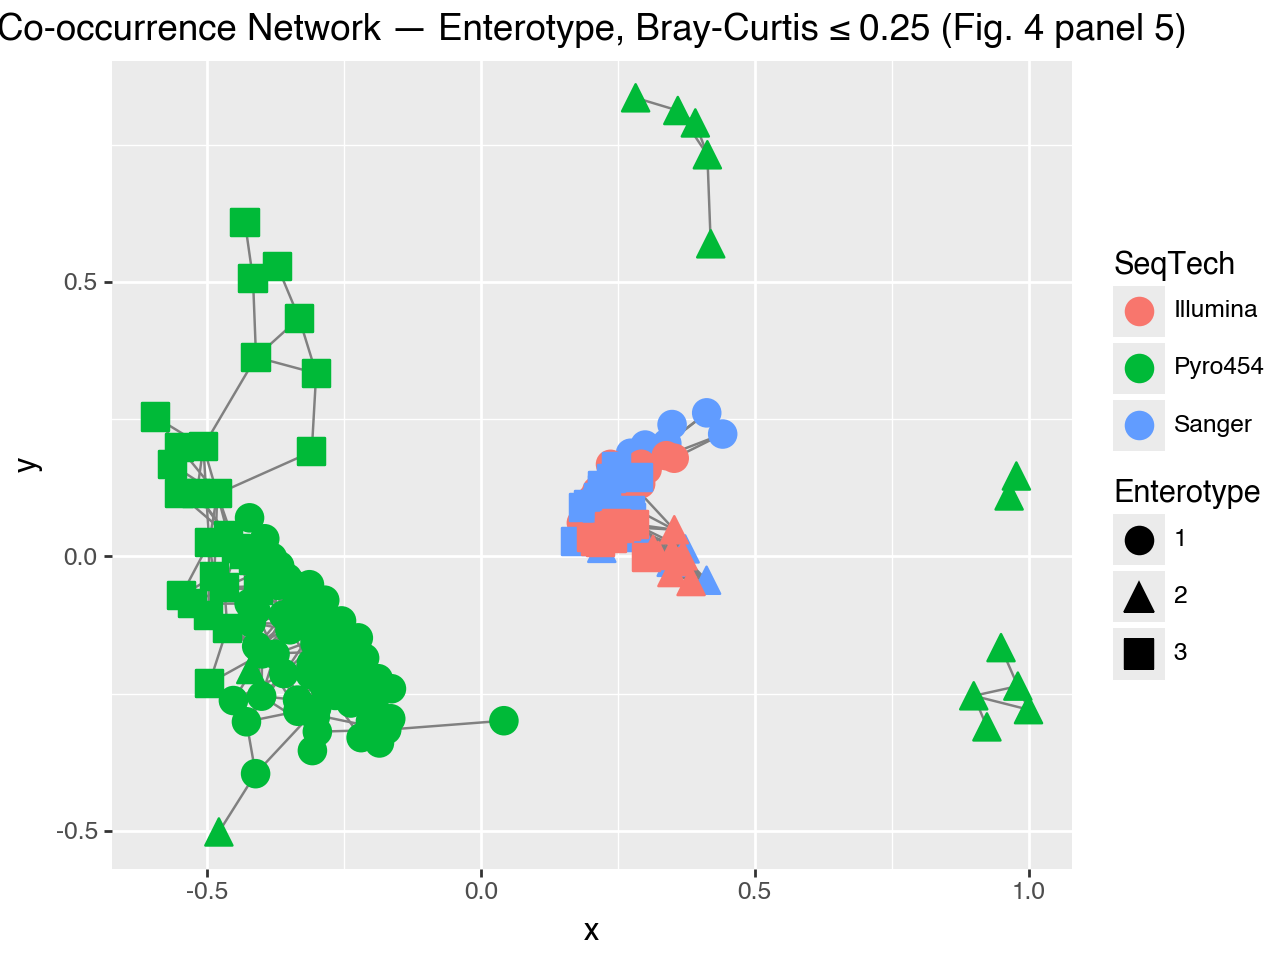

In [22]:
# Figure 4, panel 5: co-occurrence network colored by SeqTech, shaped by Enterotype
# R: plot_network(ig, enterotype, "samples", color="SeqTech", shape="Enterotype", ...)
g = make_network(
    et_labeled,
    kind="samples",
    distance="bray",
    max_dist=0.25,
    keep_isolates=False,
)
print(f"Network: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges")

p = plot_network(
    g,
    et_labeled,
    color="SeqTech",
    shape="Enterotype",
    line_weight=0.5,
    line_alpha=1.0,
    title="Co-occurrence Network — Enterotype, Bray-Curtis ≤ 0.25 (Fig. 4 panel 5)",
)
display(p)

### 2.3 Multiple Hypothesis Testing — Table 1

The paper uses `mt()` to test each genus for differential abundance across enterotype
groups using the Westfall-Young permutation FWER procedure. `pyloseq` now implements
this as `multi_tax_test()`.

Because `multi_tax_test` requires exactly two groups, we subset to enterotypes 1 and 2
for this demonstration — the most common pairing in the original paper's Table 1.

In [23]:
# Subset to enterotypes 1 and 2
et_12 = subset_samples(
    et_labeled,
    lambda s: str(s["Enterotype"]) in ("1", "2"),
)
print(f"Enterotype 1: {(et_12.get_variable('Enterotype') == '1').sum()} samples")
print(f"Enterotype 2: {(et_12.get_variable('Enterotype') == '2').sum()} samples")

Enterotype 1: 168 samples
Enterotype 2: 35 samples


In [24]:
# Table 1 equivalent: Westfall-Young step-down FWER, Welch t-test per genus
results_wy = multi_tax_test(
    et_12,
    grouping_var="Enterotype",
    test="t",
    method="westfall_young",
    n_permutations=500,
    rng_seed=42,
)
print(f"Tested {len(results_wy)} genera")
print(f"Significant at FWER < 0.05: {(results_wy['adjp'] < 0.05).sum()}")
results_wy.head(15)

Tested 553 genera
Significant at FWER < 0.05: 6


,statistic,rawp,adjp,mean_1,mean_2
Prevotella,-11.843738,1.242685e-13,0.000,0.004102,0.279499
Bacteroides,12.361952,2.765255e-23,0.000,0.273717,0.085530
Alistipes,5.462945,1.423376e-07,0.006,0.030591,0.011999
Holdemania,5.303646,9.798711e-07,0.010,0.000549,0.000244
Acetivibrio,4.717663,4.469907e-06,0.038,0.000151,0.000044
Parabacteroides,4.734973,5.330277e-06,0.038,0.014079,0.007065
Akkermansia,4.380274,1.964973e-05,0.050,0.003719,0.000526
Ruminococcaceae,4.263357,3.099005e-05,0.068,0.005113,0.001389
Parasutterella,3.767880,2.246887e-04,0.220,0.003650,0.000848
Roseburia,3.692089,3.185494e-04,0.258,0.044311,0.024901


In [25]:
# BH-FDR for comparison (less conservative)
results_bh = multi_tax_test(
    et_12,
    grouping_var="Enterotype",
    test="t",
    method="BH",
)
print(f"Significant at FDR < 0.05: {(results_bh['adjp'] < 0.05).sum()}")
results_bh.head(10)

Significant at FDR < 0.05: 220


,statistic,rawp,adjp,mean_1,mean_2
Bacteroides,12.361952,2.765255e-23,1.529186e-20,0.273717,0.085530
Prevotella,-11.843738,1.242685e-13,3.436023e-11,0.004102,0.279499
Alistipes,5.462945,1.423376e-07,2.623757e-05,0.030591,0.011999
Holdemania,5.303646,9.798711e-07,1.354672e-04,0.000549,0.000244
Acetivibrio,4.717663,4.469907e-06,4.912738e-04,0.000151,0.000044
Parabacteroides,4.734973,5.330277e-06,4.912738e-04,0.014079,0.007065
Akkermansia,4.380274,1.964973e-05,1.552329e-03,0.003719,0.000526
Ruminococcaceae,4.263357,3.099005e-05,2.142187e-03,0.005113,0.001389
Parasutterella,3.767880,2.246887e-04,1.380587e-02,0.003650,0.000848
Roseburia,3.692089,3.185494e-04,1.761578e-02,0.044311,0.024901


---
## Dataset 3: Esophagus

**Original study:** Pei et al. (2004), *PNAS*

16S rRNA clone library sequencing of human esophageal biota from 3 subjects with a phylogenetic tree. The primary role in the paper is to demonstrate the `distance()` interface.

### 3.1 Load and Inspect

In [26]:
raw_es = load_esophagus_reference()

esophagus = Phyloseq(
    otu=OtuTable(raw_es["otu_table"]),
    sam=SampleData(raw_es["sample_data"]) if "sample_data" in raw_es else None,
    tree=PhyTree.from_newick(raw_es["phy_tree_newick"]),
)

print(f"Taxa:    {esophagus.ntaxa}")
print(f"Samples: {esophagus.nsamples}")
print(f"Samples: {list(esophagus.sample_names)}")

Taxa:    58
Samples: 3
Samples: ['B', 'C', 'D']


### 3.2 UniFrac Distance Calculation

The paper uses `distance(esophagus)` to compute pairwise **unweighted UniFrac** distances, demonstrating that pyloseq integrates phylogenetic information into distance calculations.

In [27]:
# Unweighted UniFrac distance matrix (requires phylogenetic tree)
dm_unifrac = distance(esophagus, method="unifrac")

print("Unweighted UniFrac distance matrix (3 × 3):")
dm_df = pd.DataFrame(
    dm_unifrac.data,
    index=dm_unifrac.ids,
    columns=dm_unifrac.ids,
)
print(dm_df.to_string(float_format="{:.4f}".format))

Unweighted UniFrac distance matrix (3 × 3):
       B      C      D
B 0.0000 0.5176 0.5182
C 0.5176 0.0000 0.5422
D 0.5182 0.5422 0.0000


In [28]:
# Weighted UniFrac for comparison
dm_wunifrac = distance(esophagus, method="wunifrac")

print("Weighted UniFrac distance matrix:")
dm_wdf = pd.DataFrame(
    dm_wunifrac.data,
    index=dm_wunifrac.ids,
    columns=dm_wunifrac.ids,
)
print(dm_wdf.to_string(float_format="{:.4f}".format))

Weighted UniFrac distance matrix:
       B      C      D
B 0.0000 0.2035 0.2603
C 0.2035 0.0000 0.2477
D 0.2603 0.2477 0.0000


---
## Dataset 4: Soilrep

**Original study:** Zhou et al. (2011), *ISME Journal*

16S rRNA amplicon sequencing from a long-term global change experiment. 24 soil microbial community samples in a 2×2 factorial design: **Warmed** × **Clipped**. No phylogenetic tree. Used to demonstrate alpha diversity across treatment groups and to assess reproducibility of community profiling.

### 4.1 Load and Inspect

In [29]:
raw_sr = load_soilrep_reference()

soilrep = Phyloseq(
    otu=OtuTable(raw_sr["otu_table"]),
    sam=SampleData(raw_sr["sample_data"]),
)

print(f"Taxa:    {soilrep.ntaxa}")
print(f"Samples: {soilrep.nsamples}")
print(f"Sample variables: {soilrep.sample_variables}")

Taxa:    16825
Samples: 56
Sample variables: ['Treatment', 'warmed', 'clipped', 'Sample']


In [30]:
# Inspect the 2x2 factorial design
sam_df = soilrep.sample_data.to_frame()
print(sam_df.head(10))
print("\nTreatment counts:")
print(sam_df["Treatment"].value_counts() if "Treatment" in sam_df.columns
      else sam_df.iloc[:, :3])

       Treatment warmed clipped Sample
a_C026        UC     no     yes    6CC
a_C066        UU     no      no    3UC
a_C070        WU    yes      no    5UW
a_C074        UU     no      no    2UC
a_C075        WC    yes     yes    5CW
a_C077        WU    yes      no    4UW
a_C079        UU     no      no    6UC
a_C081        UC     no     yes    3CC
a_C082        UC     no     yes    1CC
a_C083        UU     no      no    6UC

Treatment counts:
Treatment
UC    14
UU    14
WC    14
WU    14
Name: count, dtype: int64


### 4.2 Alpha Diversity

The paper reports no convincing difference in species richness between warmed and unwarmed soils — the null hypothesis (no treatment effect) is not rejected.

Using 'Treatment' as x-axis


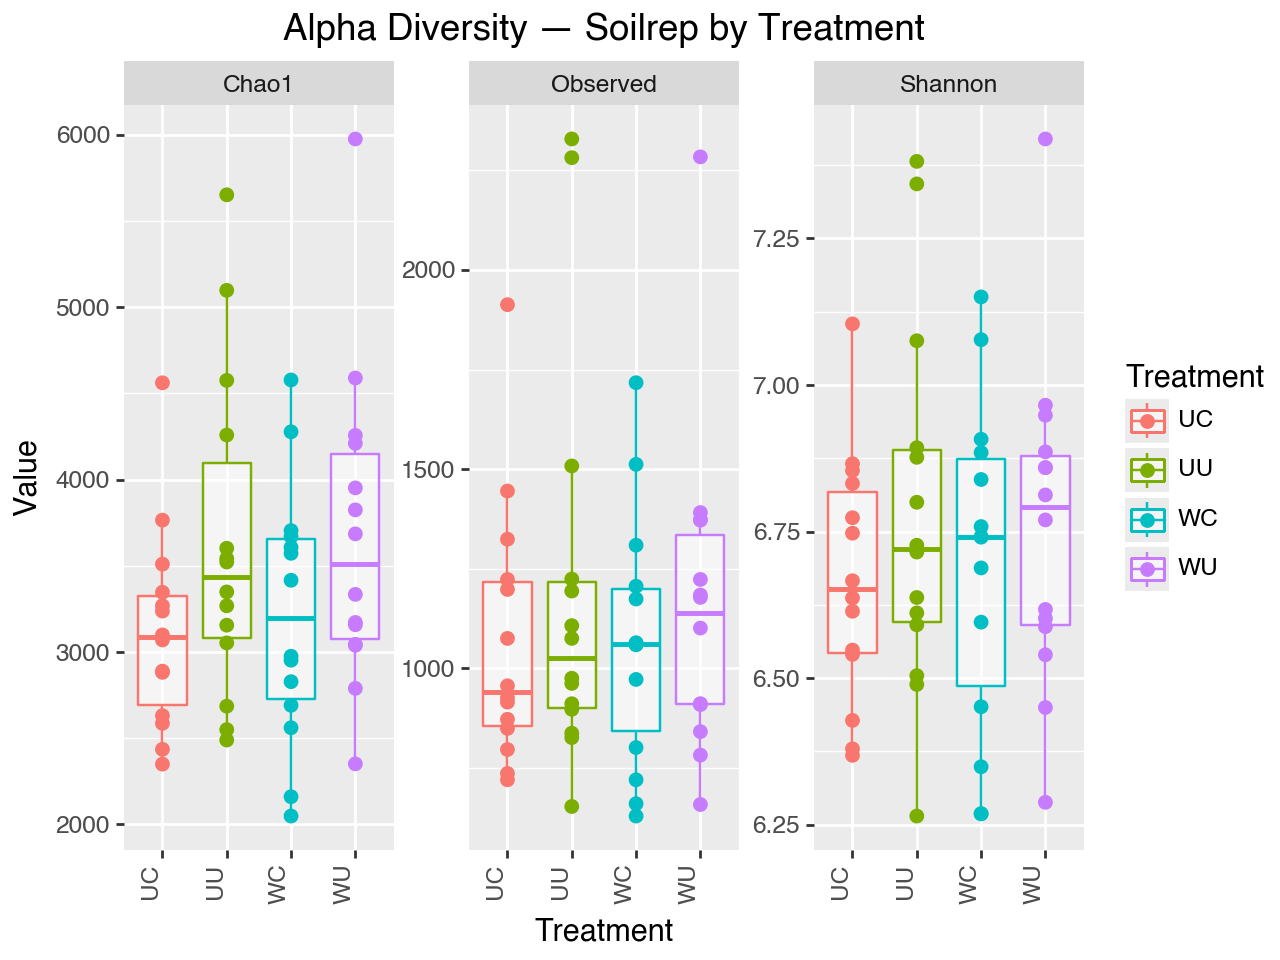

In [31]:
# Determine the x-axis variable
sr_sam_df = soilrep.sample_data.to_frame()
x_var = "Treatment" if "Treatment" in sr_sam_df.columns else sr_sam_df.columns[0]
print(f"Using '{x_var}' as x-axis")

p = plot_richness(
    soilrep,
    x=x_var,
    color=x_var,
    measures=["Observed", "Chao1", "Shannon"],
    title="Alpha Diversity — Soilrep by Treatment",
)
p

---
## Using pyloseq data in other packages — Python bioenv

The R paper demonstrates using `vegan::bioenv()` to find the subset of continuous environmental variables whose Euclidean distances best correlate (Spearman Mantel r) with the Bray-Curtis community distances. This is a model-free way to identify which measured covariates explain community composition.

The Python equivalent uses `scipy.spatial.distance` for distance matrices and `scipy.stats.spearmanr` for the Mantel correlation. The `veganotu()` helper in R extracts an OTU table as a plain matrix; in Python this is just `.to_dataframe()` with a possible transpose.

In [37]:
# Python equivalent of veganotu(): extract OTU table as a samples × taxa matrix
# R: veganotu = function(physeq) { OTU <- otu_table(physeq); if(taxa_are_rows) OTU <- t(OTU); as(OTU, "matrix") }
otu_for_bioenv = enterotype.otu_table.to_dataframe()
if enterotype.otu_table.taxa_are_rows:
    otu_for_bioenv = otu_for_bioenv.T  # taxa × samples → samples × taxa
print(f"OTU matrix shape: {otu_for_bioenv.shape}  (samples × taxa)")

# Identify numeric environmental variables (R: keepvariables = which(sapply(sample_data, is.numeric)))
sam_df_et = enterotype.sample_data.to_frame()
numeric_cols = sam_df_et.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric sample variables: {numeric_cols}")

ent_env = sam_df_et[numeric_cols].copy()

# Add simulated continuous variables (matching R's sample(seq(0, 1, 0.02), ...))
rng = np.random.default_rng(42)
ent_env["sim1"] = rng.choice(np.arange(0, 1.02, 0.02), size=enterotype.nsamples)
ent_env["sim2"] = rng.choice(np.arange(0, 1.02, 0.02), size=enterotype.nsamples)

# Fill missing Age values (R: ent$Age[is.na(ent$Age)] = sample(1:92, ...))
age_na = ent_env["Age"].isna()
ent_env.loc[age_na, "Age"] = rng.integers(1, 93, size=int(age_na.sum()))

print(f"\nEnvironmental data — {ent_env.shape[0]} samples × {ent_env.shape[1]} variables")
ent_env.describe()

OTU matrix shape: (280, 553)  (samples × taxa)
Numeric sample variables: ['Age']

Environmental data — 280 samples × 3 variables


,Age,sim1,sim2
count,280.000000,280.000000,280.000000
mean,47.797000,0.498214,0.502429
std,26.225798,0.279346,0.307362
min,0.250000,0.000000,0.000000
25%,25.750000,0.275000,0.240000
50%,49.000000,0.500000,0.500000
75%,68.500000,0.740000,0.785000
max,92.000000,1.000000,1.000000


In [ ]:
from itertools import combinations

from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

# Condensed Bray-Curtis community distance vector (length n*(n-1)/2)
comm_flat = pdist(otu_for_bioenv.values.astype(float), metric="braycurtis")

# Try all subsets of environmental variables and rank by Spearman Mantel r
vars_list = ent_env.columns.tolist()
results = []
for k in range(1, len(vars_list) + 1):
    for subset in combinations(vars_list, k):
        env_vals = ent_env[list(subset)].values.astype(float)
        env_flat = pdist(env_vals, metric="euclidean")
        r, _ = spearmanr(comm_flat, env_flat)
        results.append({"variables": " + ".join(subset), "n_vars": k, "spearman_r": round(r, 4)})

bioenv_df = (
    pd.DataFrame(results)
    .sort_values("spearman_r", ascending=False)
    .reset_index(drop=True)
)
print(f"Best subset:  {bioenv_df.iloc[0]['variables']}  (r = {bioenv_df.iloc[0]['spearman_r']:.4f})")
print(f"Worst subset: {bioenv_df.iloc[-1]['variables']}  (r = {bioenv_df.iloc[-1]['spearman_r']:.4f})")
bioenv_df.head(15)

Best subset:  Age + sim1  (r = 0.0190)
Worst subset: sim2  (r = -0.0065)


,variables,n_vars,spearman_r
0,Age + sim1,2,0.0190
1,Age + sim1 + sim2,3,0.0188
2,Age,1,0.0187
3,Age + sim2,2,0.0185
4,sim1,1,0.0164
5,sim1 + sim2,2,0.0074
6,sim2,1,-0.0065


---
## Summary

### Analyses reproduced

| Analysis | Paper | pyloseq function | Dataset |
|---|---|---|---|
| Preprocessing — prevalence filter | — | `filter_taxa` + `kOverA` | GlobalPatterns |
| Preprocessing — depth normalization (with rounding) | — | `transform_sample_counts` | GlobalPatterns |
| Preprocessing — CV filter | — | `filter_taxa` | GlobalPatterns |
| Preprocessing — taxonomic subset | — | `subset_taxa` | GlobalPatterns |
| Alpha diversity (human vs. non-human x-axis) | Fig. 4 p6 | `plot_richness` | GlobalPatterns |
| Taxonomic bar chart (Bacteroidetes, by Family) | Fig. 4 p5 | `plot_bar` | GlobalPatterns |
| Phylogenetic tree (tip_glom + merge_samples) | Fig. 4 p4 | `tip_glom` + `merge_samples` + `plot_tree` | GlobalPatterns |
| Heatmap (NMDS/Bray-Curtis ordering) | Fig. 4 p2 | `plot_heatmap` | GlobalPatterns |
| NMDS + Weighted UniFrac ordination | Fig. 5 p1 | `ordinate` + `plot_ordination` | GlobalPatterns |
| CA scree plot | Fig. 5 inset | `plot_ordination(kind="scree")` | GlobalPatterns |
| CA ordination — samples | Fig. 5 p2 | `plot_ordination(kind="samples")` | GlobalPatterns |
| CA ordination — taxa (facet + density) | Fig. 5 p3 | `plot_ordination(kind="taxa")` + `facet_wrap` + `geom_density_2d` | GlobalPatterns |
| CA ordination — biplot (with Class shape) | Fig. 5 p4 | `plot_ordination(kind="biplot")` | GlobalPatterns |
| CA ordination — split (with Class shape) | Fig. 5 p5 | `plot_ordination(kind="split")` | GlobalPatterns |
| Co-occurrence network (SeqTech color, Enterotype shape) | Fig. 4 p3 | `make_network` + `plot_network` | Enterotype |
| Multiple hypothesis testing (Westfall-Young FWER) | Table 1 | `multi_tax_test` | Enterotype |
| BH-FDR differential abundance | Table 1 | `multi_tax_test` | Enterotype |
| Python bioenv equivalent (Mantel-based subset selection) | Methods | `scipy` + `skbio` | Enterotype |
| UniFrac distance matrix (weighted + unweighted) | Methods | `distance` | Esophagus |
| Alpha diversity (treatment groups) | Methods | `plot_richness` | Soilrep |